In [ ]:
# pip install -U \
#     langgraph \
#     langchain \
#     langchain-core \
#     langsmith

In [1]:
from typing_extensions import TypedDict
from langgraph.graph.state import StateGraph, START

# Define subgraph
class SubgraphState(TypedDict):
    # note that none of these keys are shared with the parent graph state
    bar: str
    baz: str

def subgraph_node_1(state: SubgraphState):
    return {"baz": "baz"}

def subgraph_node_2(state: SubgraphState):
    return {"bar": state["bar"] + state["baz"]}

subgraph_builder = StateGraph(SubgraphState)
subgraph_builder.add_node(subgraph_node_1)
subgraph_builder.add_node(subgraph_node_2)
subgraph_builder.add_edge(START, "subgraph_node_1")
subgraph_builder.add_edge("subgraph_node_1", "subgraph_node_2")
subgraph = subgraph_builder.compile()

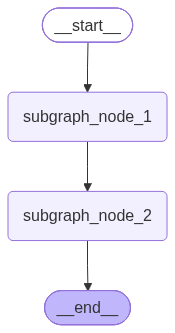

In [2]:
subgraph

In [3]:
# Define parent graph
class ParentState(TypedDict):
    foo: str

def node_1(state: ParentState):
    return {"foo": "hi! " + state["foo"]}

def node_2(state: ParentState):
    # Transform the state to the subgraph state
    response = subgraph.invoke({"bar": state["foo"]})
    # Transform response back to the parent state
    return {"foo": response["bar"]}


builder = StateGraph(ParentState)
builder.add_node("node_1", node_1)
builder.add_node("node_2", node_2)
builder.add_edge(START, "node_1")
builder.add_edge("node_1", "node_2")
graph = builder.compile()

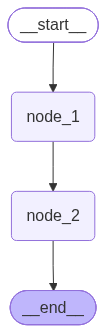

In [4]:
graph

In [9]:
stream = graph.stream_events(
    {"foo": "foo"},
    version="v3",
)

for event in stream:
    if event["method"] == "values":
        ns = event["params"]["namespace"]
        data = event["params"]["data"]

        if ns:
            print(f"Subgraph {ns}: {data}")
        else:
            print(f"Root: {data}")

Root: {'foo': 'foo'}
Root: {'foo': 'hi! foo'}
Subgraph ['node_2:6312b618-5d46-f7a8-7e1d-622cdeeec0b7']: {'bar': 'hi! foo'}
Subgraph ['node_2:6312b618-5d46-f7a8-7e1d-622cdeeec0b7']: {'bar': 'hi! foo', 'baz': 'baz'}
Subgraph ['node_2:6312b618-5d46-f7a8-7e1d-622cdeeec0b7']: {'bar': 'hi! foobaz', 'baz': 'baz'}
Root: {'foo': 'hi! foobaz'}


---

# 2 Level of Subgraph (parent -> child -> grandchild)

In [1]:
# Grandchild graph
from typing_extensions import TypedDict
from langgraph.graph.state import StateGraph, START, END

class GrandChildState(TypedDict):
    my_grandchild_key: str

def grandchild_1(state: GrandChildState) -> GrandChildState:
    # NOTE: child or parent keys will not be accessible here
    return {"my_grandchild_key": state["my_grandchild_key"] + ", how are you"}


grandchild = StateGraph(GrandChildState)
grandchild.add_node("grandchild_1", grandchild_1)

grandchild.add_edge(START, "grandchild_1")
grandchild.add_edge("grandchild_1", END)

grandchild_graph = grandchild.compile()

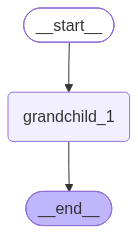

In [2]:
grandchild_graph

In [3]:
# Child graph
class ChildState(TypedDict):
    my_child_key: str

def call_grandchild_graph(state: ChildState) -> ChildState:
    # NOTE: parent or grandchild keys won't be accessible here
    grandchild_graph_input = {"my_grandchild_key": state["my_child_key"]}
    grandchild_graph_output = grandchild_graph.invoke(grandchild_graph_input)
    return {"my_child_key": grandchild_graph_output["my_grandchild_key"] + " today?"}

child = StateGraph(ChildState)
# We're passing a function here instead of just compiled graph (`grandchild_graph`)
child.add_node("child_1", call_grandchild_graph)
child.add_edge(START, "child_1")
child.add_edge("child_1", END)
child_graph = child.compile()

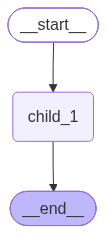

In [4]:
child_graph

In [5]:
# Parent graph
class ParentState(TypedDict):
    my_key: str

def parent_1(state: ParentState) -> ParentState:
    # NOTE: child or grandchild keys won't be accessible here
    return {"my_key": "hi " + state["my_key"]}

def parent_2(state: ParentState) -> ParentState:
    return {"my_key": state["my_key"] + " bye!"}

def call_child_graph(state: ParentState) -> ParentState:
    child_graph_input = {"my_child_key": state["my_key"]}
    child_graph_output = child_graph.invoke(child_graph_input)
    return {"my_key": child_graph_output["my_child_key"]}

parent = StateGraph(ParentState)
parent.add_node("parent_1", parent_1)
# We're passing a function here instead of just a compiled graph (`child_graph`)
parent.add_node("child", call_child_graph)
parent.add_node("parent_2", parent_2)

parent.add_edge(START, "parent_1")
parent.add_edge("parent_1", "child")
parent.add_edge("child", "parent_2")
parent.add_edge("parent_2", END)

parent_graph = parent.compile()

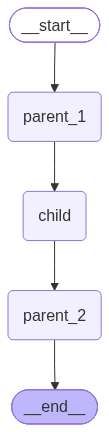

In [6]:
parent_graph

In [7]:
for event in parent_graph.stream_events(
    {"my_key": "Bob"},
    version="v3",
):
    if event["method"] == "values":
        print(
            event["params"]["namespace"],
            event["params"]["data"],
        )

[] {'my_key': 'Bob'}
[] {'my_key': 'hi Bob'}
['child:8ccfde1a-e0b7-4993-b95a-390f2927c636'] {'my_child_key': 'hi Bob'}
['child:8ccfde1a-e0b7-4993-b95a-390f2927c636', 'child_1:d7426624-4365-49c1-e6e7-b0c20f4d6980'] {'my_grandchild_key': 'hi Bob'}
['child:8ccfde1a-e0b7-4993-b95a-390f2927c636', 'child_1:d7426624-4365-49c1-e6e7-b0c20f4d6980'] {'my_grandchild_key': 'hi Bob, how are you'}
['child:8ccfde1a-e0b7-4993-b95a-390f2927c636'] {'my_child_key': 'hi Bob, how are you today?'}
[] {'my_key': 'hi Bob, how are you today?'}
[] {'my_key': 'hi Bob, how are you today? bye!'}


/home/ali/AI/10.LangGraph/venv/lib/python3.12/site-packages/langgraph/pregel/main.py:3708: LangChainBetaWarning: The v3 streaming protocol on Pregel is experimental.
  return self._pregel_stream_v3(
/home/ali/AI/10.LangGraph/venv/lib/python3.12/site-packages/langgraph/pregel/main.py:3558: LangChainBetaWarning: The v3 streaming protocol on Pregel is experimental.
  return GraphRunStream(graph_iter, mux)
